In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from itertools import combinations

import lightgbm as lgb
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import mean_squared_error
import optuna

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

%matplotlib inline

In [2]:
train = pd.read_csv('/kaggle/input/playground-series-s5e9/train.csv',index_col='id')
test = pd.read_csv('/kaggle/input/playground-series-s5e9/test.csv',index_col='id')

In [ ]:
train.head()

In [ ]:
train.info()

In [ ]:
train.describe()

In [ ]:
for col in train.columns:
    plt.figure(figsize=(8,6))
    sns.histplot(data=train,x=col)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [ ]:
for col in train.columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(data=train,x=col)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    train.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Between Numerical Features", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
def create_features(df):
    new_df = df.copy()
    
    for col1, col2 in combinations(df.columns,2):
        if col1 != 'BeatsPerMinute' and col2 != 'BeatsPerMinute':
            new_df[f'{col1}_{col2}_interaction'] = df[col1] * df[col2]
            new_df[f'{col1}_{col2}_ratio'] = df[col1]/(df[col2] + 1e-6)
    return new_df

In [44]:
train_processed = create_features(train)
test_processed = create_features(test)

In [46]:
X = train_processed.drop('BeatsPerMinute', axis=1).copy()
y = train_processed['BeatsPerMinute']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, shuffle=True, random_state=17)

In [47]:
model = lgb.LGBMRegressor(objective = 'regression',random_state=42,verbose=-1)

In [48]:
model.fit(X_train,y_train)

LGBMRegressor(objective='regression', random_state=42, verbose=-1)

In [49]:
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = model.score(X_train,y_train)
print(f"Root Mean Squared Error: {rmse}")
print(f"R^2: {r2}")

Root Mean Squared Error: 26.51085636111107
R^2: 0.014255292690308785


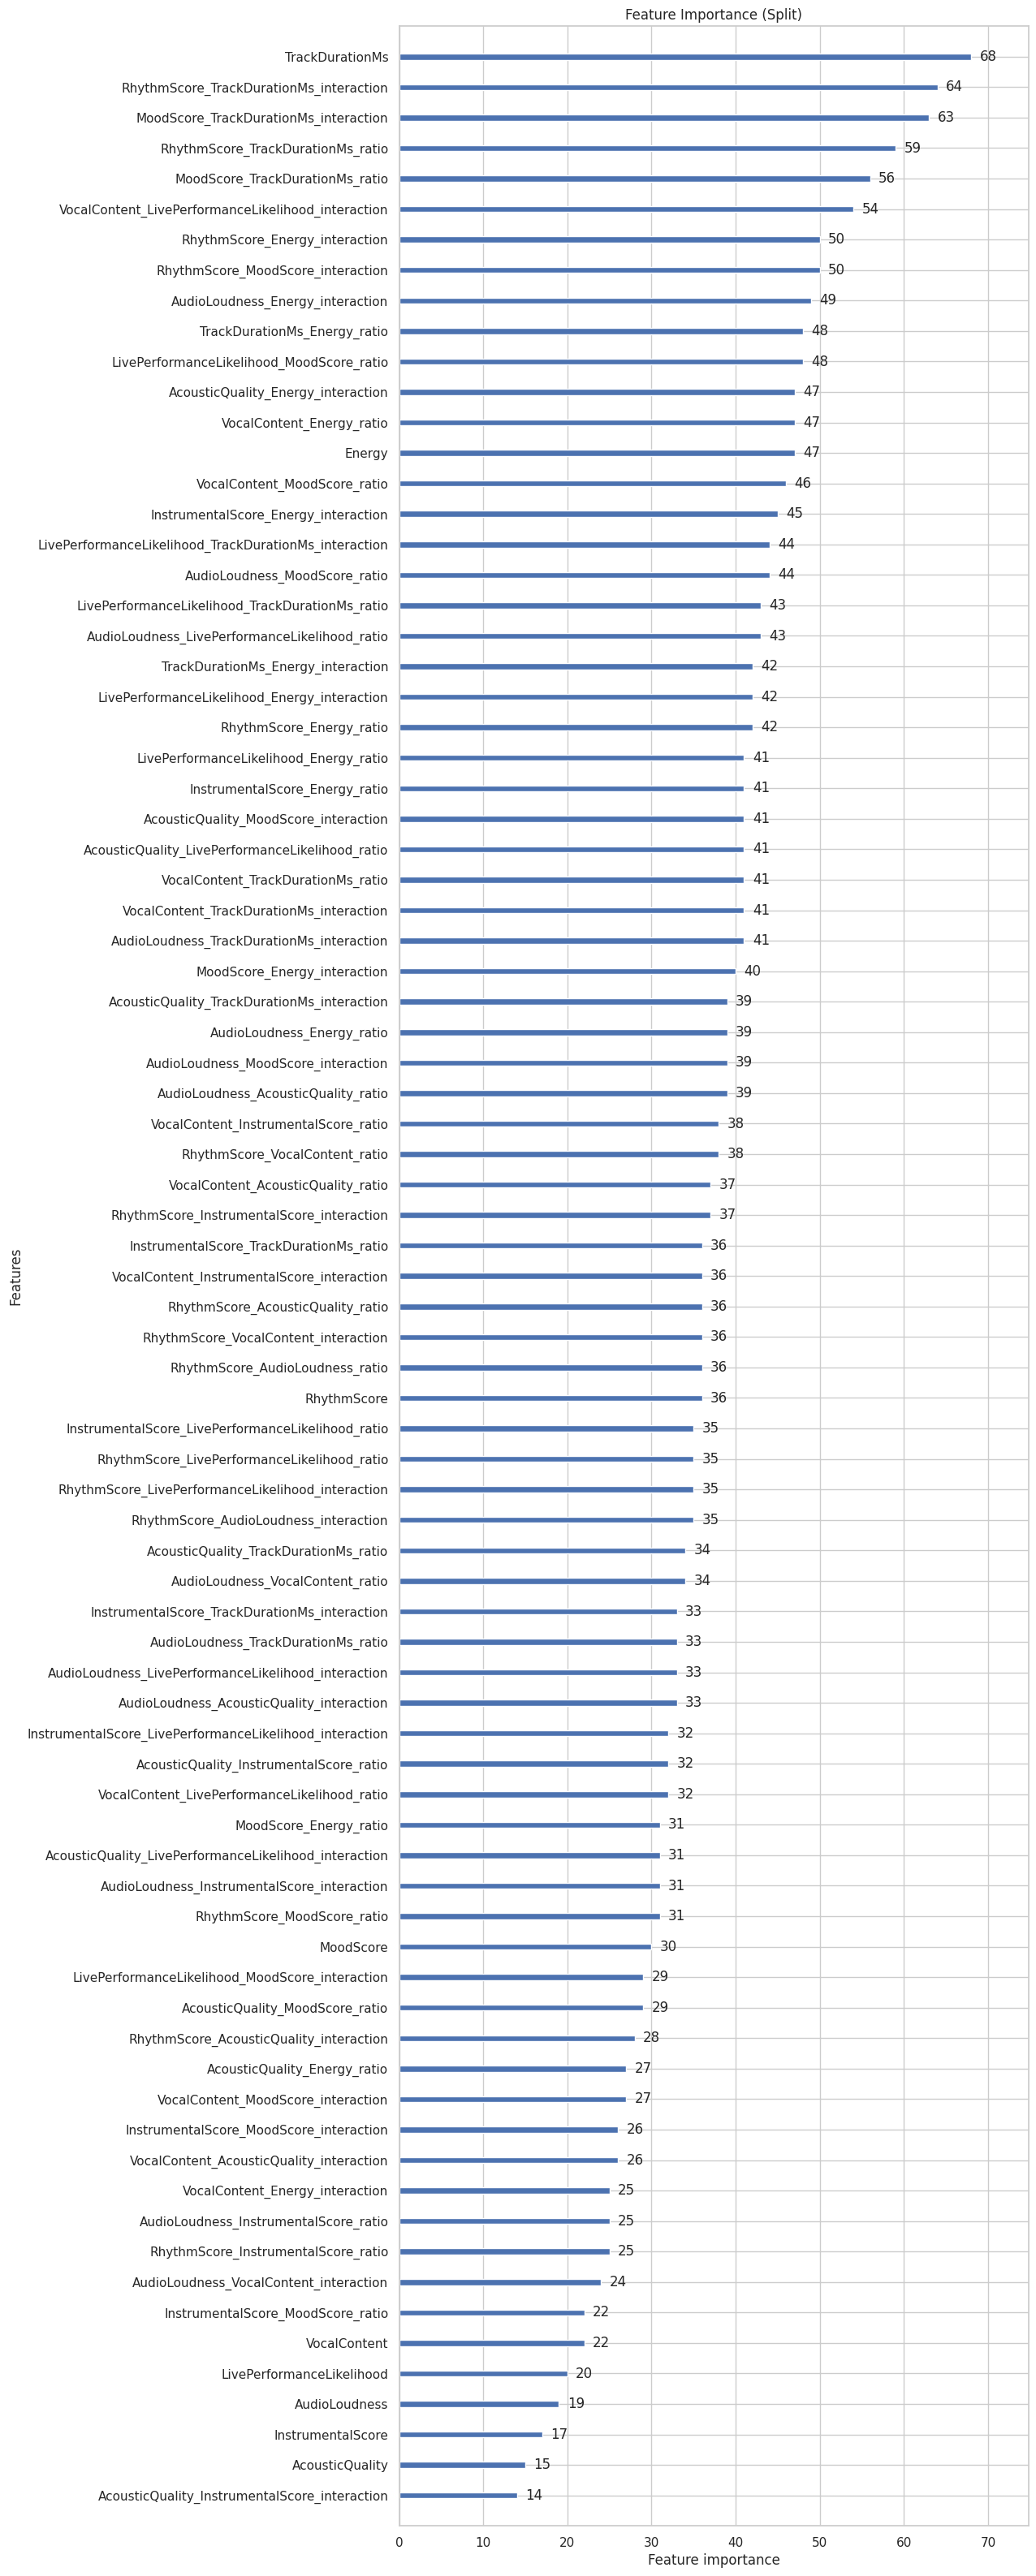

In [50]:
lgb.plot_importance(model, importance_type='split', figsize=(10, 40))
plt.title("Feature Importance (Split)")
plt.show()

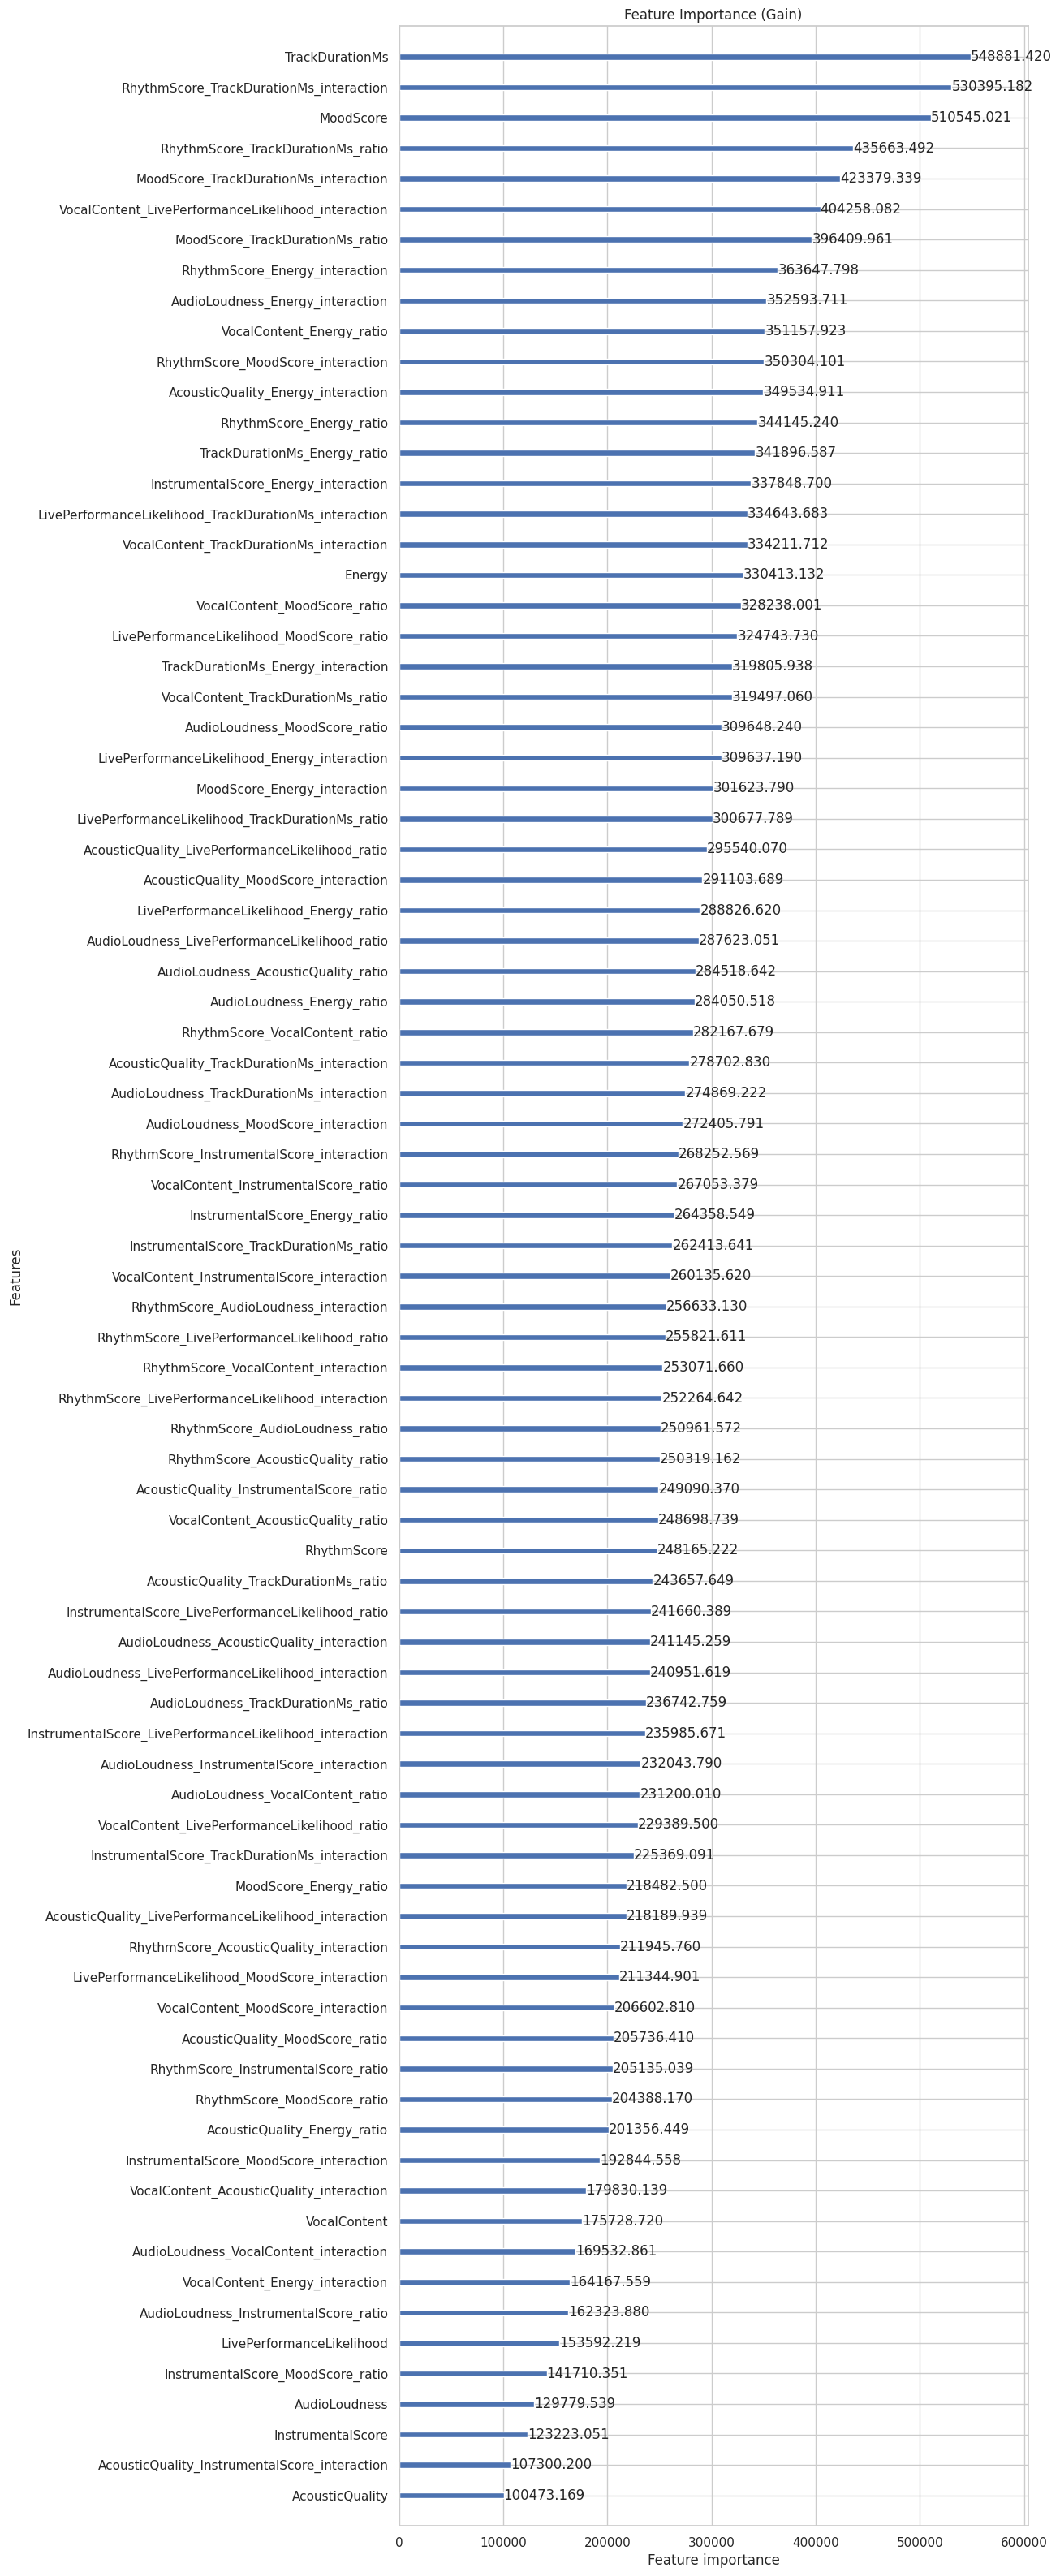

In [51]:
lgb.plot_importance(model, importance_type='gain', figsize=(10, 40))
plt.title("Feature Importance (Gain)")
plt.show()

In [52]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 1, 10),
        "num_leaves": trial.suggest_int("num_leaves", 15, 50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "device": "gpu",           
        "gpu_platform_id": 0,      
        "gpu_device_id": 0         
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores = []

    for train_idx, valid_idx in kf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = lgb.LGBMRegressor(**params)
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(5, verbose=False)],
        )
        
        preds = model.predict(X_valid, num_iteration=model.best_iteration_)
        rmse = mean_squared_error(y_valid, preds, squared=False)
        rmse_scores.append(rmse)
    
    return np.mean(rmse_scores)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best trial:")
print("  Value (mean RMSE):", study.best_trial.value)
print("  Params:", study.best_trial.params)

[I 2025-09-05 18:02:16,572] A new study created in memory with name: no-name-4e0acadc-f525-4774-9911-945c74969672
[I 2025-09-05 18:02:37,087] Trial 0 finished with value: 26.459795314108494 and parameters: {'n_estimators': 911, 'learning_rate': 0.12112923345079334, 'max_depth': 5, 'num_leaves': 23, 'subsample': 0.9597654413555958, 'colsample_bytree': 0.9166438923368772, 'reg_alpha': 0.0015266129761920448, 'reg_lambda': 0.00036071461125920107}. Best is trial 0 with value: 26.459795314108494.
[I 2025-09-05 18:02:59,138] Trial 1 finished with value: 26.45943966226651 and parameters: {'n_estimators': 659, 'learning_rate': 0.06667789002799278, 'max_depth': 8, 'num_leaves': 39, 'subsample': 0.5047429751777566, 'colsample_bytree': 0.9490893210107225, 'reg_alpha': 3.4640234304683295, 'reg_lambda': 8.213075172098138e-06}. Best is trial 1 with value: 26.45943966226651.
[I 2025-09-05 18:03:25,494] Trial 2 finished with value: 26.459468862617246 and parameters: {'n_estimators': 835, 'learning_rate

Best trial:
  Value (mean RMSE): 26.45869787588159
  Params: {'n_estimators': 803, 'learning_rate': 0.05162507575912668, 'max_depth': 8, 'num_leaves': 18, 'subsample': 0.6689654808173896, 'colsample_bytree': 0.6432661239228752, 'reg_alpha': 0.920178697709394, 'reg_lambda': 0.1235292583959343}


In [53]:
best_params = study.best_trial.params
best_params.update({
    "device": "gpu",
    "gpu_platform_id": 0,
    "gpu_device_id": 0,
    "random_state": 42
})

best_lgb = lgb.LGBMRegressor(**best_params)
best_lgb.fit(X_train,y_train)

LGBMRegressor(colsample_bytree=0.6432661239228752, device='gpu',
              gpu_device_id=0, gpu_platform_id=0,
              learning_rate=0.05162507575912668, max_depth=8, n_estimators=803,
              num_leaves=18, random_state=42, reg_alpha=0.920178697709394,
              reg_lambda=0.1235292583959343, subsample=0.6689654808173896)

In [54]:
y_pred = best_lgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = best_lgb.score(X_train,y_train)
print(f"Root Mean Squared Error: {rmse}")
print(f"R^2: {r2}")

Root Mean Squared Error: 26.52453246733794
R^2: 0.02893655546227014


In [55]:
submission = pd.read_csv("/kaggle/input/playground-series-s5e9/sample_submission.csv")
submission['BeatsPerMinute'] = best_lgb.predict(test_processed)
submission.to_csv("submission.csv", index=False)